In [39]:
import uproot
import awkward as ak
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import hist
import vector
import os
import subprocess
import gc
from scipy.optimize import curve_fit
print("uproot version",uproot.__version__)
print("awkward version",ak.__version__)
print("numpy version",np.__version__)
print("matplotlib version",matplotlib.__version__)
print("hist version",hist.__version__)
print("vector version",vector.__version__)

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.1.3
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2


In [7]:
vector.register_awkward()

In [8]:
folder_path = "/pbs/throng/training/nantes-m2-rps-exp/data"
results = []
j_psi_gen = []
j_psi_rec = []

file_count =0

for file_name in os.listdir(folder_path):
    if file_name.endswith(".mc.root"):
        file_path = os.path.join(folder_path, file_name)
        results.append(file_name[0:-8])

        print(f"Traitement du fichier : {file_name}")
        file = uproot.open(file_path)

        gen = file["genTree"]
        n = gen.arrays([
            "nMuonsGen",
            "Muon_GenPx",
            "Muon_GenPy",
            "Muon_GenPz",
            "Muon_GenE",
            "Muon_GenLabel",
            "Muon_GenMotherPDGCode"
        ])

        nMuonsGen = 0
        for i in range(len(n)):
            info = n[i]["nMuonsGen"]
            nMuonsGen += info
        print("nMuonsGen = ", nMuonsGen)

        events = file["eventsTree"]
        m = events.arrays([
            "zVtx",
            "isCMUL",
            "nMuons",
            "Muon_Px",
            "Muon_Py",
            "Muon_Pz",
            "Muon_E",
            "Muon_Charge",
            "Muon_thetaAbs",
            "Muon_matchedTrgThreshold",
            "Muon_MCLabel"
        ])

        nMuons = 0
        for i in range(len(m)):
            info = m[i]["nMuons"]
            nMuons += info
        print("nMuons = ", nMuons)

        #-------------------------------------Pour 5 fichier seulement---------a supprimer plus tard (supprimer l'affichage surtout)--------------------
        file_count += 1
        #file_count >= 5
        if file_count >= 5 :
            print("Limite de fichiers atteinte.")
            break
            
        mask = (m["nMuons"] >= 2) & ak.all(n["Muon_GenMotherPDGCode"] == 443, axis=1)
        filtered_gen_events = n[ak.all(n["Muon_GenMotherPDGCode"] == 443, axis=1)]
        filtered_events = m[mask & (m.isCMUL)&(abs(m.zVtx)<10)]
        print("nombre de Jpsi généré : ",len(filtered_gen_events))
        print("nombre de Jpsi reconstruit : ",len(filtered_events))
        j_psi_gen.append(len(filtered_gen_events))
        j_psi_rec.append(len(filtered_events))

#print(results)
#print(pT)


Traitement du fichier : run292140.mc.root
nMuonsGen =  14000
nMuons =  7742
nombre de Jpsi généré :  4681
nombre de Jpsi reconstruit :  943
Traitement du fichier : run290721.mc.root
nMuonsGen =  40000
nMuons =  21341
nombre de Jpsi généré :  13419
nombre de Jpsi reconstruit :  2546
Traitement du fichier : run292160.mc.root
nMuonsGen =  260000
nMuons =  143259
nombre de Jpsi généré :  86554
nombre de Jpsi reconstruit :  17549
Traitement du fichier : run291976.mc.root
nMuonsGen =  140000
nMuons =  77005
nombre de Jpsi généré :  46668
nombre de Jpsi reconstruit :  9322
Traitement du fichier : run291944.mc.root
nMuonsGen =  100000
nMuons =  55365
Limite de fichiers atteinte.


In [9]:
        ################################### calcul du pT pour les Jpsi reconstruit ###################################
        muon_vectors = ak.zip({
            "px": filtered_events.Muon_Px,
            "py": filtered_events.Muon_Py,
            "pz": filtered_events.Muon_Pz,
            "E": filtered_events.Muon_E
        }, with_name="Momentum4D")

        jpsi_combi = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
        pT = (jpsi_combi.muon1 + jpsi_combi.muon2).pt

################################### calcul du pT pour les Jpsi généré ###################################
        muon_vectors_gen = ak.zip({
            "px": filtered_gen_events.Muon_GenPx,
            "py": filtered_gen_events.Muon_GenPy,
            "pz": filtered_gen_events.Muon_GenPz,
            "E": filtered_gen_events.Muon_GenE
        }, with_name="Momentum4D")

        jpsi_combi_gen = ak.combinations(muon_vectors_gen, 2, fields=["muonA", "muonB"])
        pT_gen = (jpsi_combi_gen.muonA + jpsi_combi_gen.muonB).pt

print("pT_rec : ", pT)
print("pT_gen : ", pT_gen)

pT_rec :  [[5.14], [1.38], [0.918], [2.62], [1.46], ..., [2.61], [4.64], [1.59], [3.08]]
pT_gen :  [[1.21], [5.43], [2.4], [0.444], [1.22], ..., [2.1], [1.56], [10.5], [2.54]]


In [10]:
#print(j_psi_gen)
#print(j_psi_rec)
print(len(pT))
#for i in pT :
 #   print(np.max(pT))
#print("tout les pT = ", pT)
#print(type(pT))
pT_min = []
pT_max = []
pT_f = ak.flatten(pT)  # Aplatir si c'est un awkward-array
for i in pT_f:
    if i <6:
        pT_min.append(i)
    else:
        pT_max.append(i)

N_rec, Bins_rec = np.histogram(pT_f,bins=20,range = (0,10)) #N_rec est le nombre de Jpsi reconstruit dans chaque intervalle en pT
print("pT = ", Bins_rec)

pT_gen_f = ak.flatten(pT_gen)  # Aplatir si c'est un awkward-array
pT_min_gen = []
pT_max_gen = []
for i in pT_gen_f:
    if i <6:
        pT_min_gen.append(i)
    else:
        pT_max_gen.append(i)
        
N_gen, Bins_gen = np.histogram(pT_gen_f,bins=20,range = (0,10)) #N_gen est le nombre de Jpsi généré dans chaque intervalle en pT
print("pT_gen = ", Bins_gen)
print("N_gen = ", N_gen)
print("N_rec = ", N_rec)

#print("len pT = ", len(Bins))
######################################### calcul de l'acceptance efficacité ##########################################
err_N_rec = [(N_rec[i])**(0.5) for i in range(len(N_rec))]
err_N_gen = [(N_gen[i])**(0.5) for i in range(len(N_gen))]
acceptance_eff = [float(N_rec[i]/N_gen[i]) for i in range(len(N_rec))]
err_acceptance_eff = [float(((err_N_rec[i]**2)/(N_rec[i]**2) + (err_N_gen[i]**2)/(N_gen[i]**2))**(0.5)) for i in range(len(N_rec))] #delta(AxE)/(AxE)

print("acceptance_eff = ",acceptance_eff, "+/- ",err_acceptance_eff)

9322
pT =  [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, ..., 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10]
pT_gen =  [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, ..., 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10]
N_gen =  [1.88e+03, 4.89e+03, 6.42e+03, 6.6e+03, 5.96e+03, ..., 297, 206, 154, 140, 101]
N_rec =  [348, 887, 1.17e+03, 1.16e+03, 1.06e+03, 884, 737, ..., 123, 98, 75, 52, 49, 43]
acceptance_eff =  [0.18481147105682422, 0.18146481178396073, 0.18262494161606727, 0.17631020902756742, 0.17810978680543899, 0.17658809428685576, 0.18729351969504449, 0.20625841184387617, 0.2258485639686684, 0.23830049261083744, 0.24710743801652893, 0.2849740932642487, 0.28864569083447333, 0.2961460446247465, 0.3324324324324324, 0.32996632996632996, 0.3640776699029126, 0.33766233766233766, 0.35, 0.42574257425742573] +/-  [0.05834921305344565, 0.036496278814249564, 0.03175225041351098, 0.031789554588756326, 0.03332231687458332, 0.036482626099443936, 0.040137036627283164, 0.04435983684998241, 0.04859982801591611, 0.05656626976355612, 0.06458

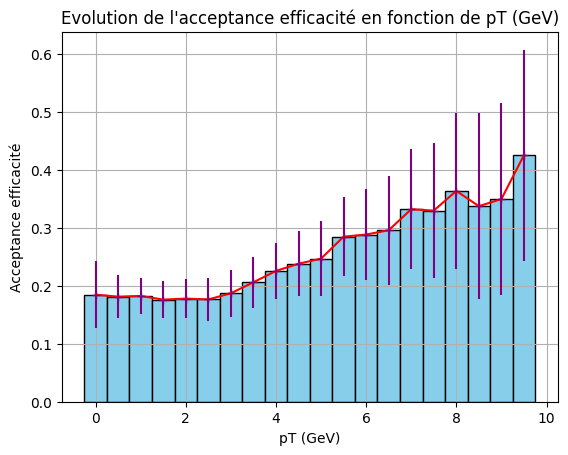

In [11]:
######################################### évolution de l'acceptance efficacité en fonction de pT ##########################################
plt.figure()       
plt.errorbar(Bins_rec[:-1],acceptance_eff, yerr=err_acceptance_eff, fmt='+',color = 'purple', label = 'erreur')
width = 10/len(Bins_rec[:-1])
plt.bar(Bins_rec[:-1], acceptance_eff,width = width, edgecolor='black', color='skyblue')
#plt.hist(Bins_rec[1:])
plt.plot(Bins_rec[:-1], acceptance_eff,'r')
plt.xlabel('pT (GeV)')
plt.ylabel("Acceptance efficacité")
plt.title("Evolution de l'acceptance efficacité en fonction de pT (GeV)")
plt.grid(True)
plt.show()

In [12]:
######################## séparation des gammes en énergie pour pT ############################################
N_rec_min, Bins_rec_min = np.histogram(pT_min,bins=12,range = (0,6)) #N_rec est le nombre de Jpsi reconstruit dans chaque intervalle en pT
print("pT = ", Bins_rec_min)

N_rec_max, Bins_rec_max = np.histogram(pT_max,bins=4,range = (6,10)) #N_rec est le nombre de Jpsi reconstruit dans chaque intervalle en pT
print("pT = ", Bins_rec_max)

N_gen_min, Bins_gen_min = np.histogram(pT_min_gen,bins=12,range = (0,6)) #N_gen est le nombre de Jpsi généré dans chaque intervalle en pT
print("pT = ", Bins_gen_min)

N_gen_max, Bins_gen_max = np.histogram(pT_max_gen,bins=4,range = (6,10)) #N_gen est le nombre de Jpsi généré dans chaque intervalle en pT
print("pT = ", Bins_gen_max)

######################################### calcul de l'acceptance efficacité ##########################################
err_N_rec_min = [(N_rec_min[i])**(0.5) for i in range(len(N_rec_min))]
err_N_rec_max = [(N_rec_max[i])**(0.5) for i in range(len(N_rec_max))]

err_N_gen_min = [(N_gen_min[i])**(0.5) for i in range(len(N_gen_min))]
err_N_gen_max = [(N_gen_max[i])**(0.5) for i in range(len(N_gen_max))]

acceptance_eff_min = [float(N_rec_min[i]/N_gen_min[i]) for i in range(len(N_rec_min))]
acceptance_eff_max = [float(N_rec_max[i]/N_gen_max[i]) for i in range(len(N_rec_max))]

err_acceptance_eff_min = [float(((err_N_rec_min[i]**2)/(N_rec_min[i]**2) + (err_N_gen_min[i]**2)/(N_gen_min[i]**2))**(0.5)) for i in range(len(N_rec_min))] #delta(AxE)/(AxE)
err_acceptance_eff_max = [float(((err_N_rec_max[i]**2)/(N_rec_max[i]**2) + (err_N_gen_max[i]**2)/(N_gen_max[i]**2))**(0.5)) for i in range(len(N_rec_max))] #delta(AxE)/(AxE)

#print("acceptance_eff = ",acceptance_eff, "+/- ",err_acceptance_eff)

pT =  [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]
pT =  [ 6.  7.  8.  9. 10.]
pT =  [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]
pT =  [ 6.  7.  8.  9. 10.]


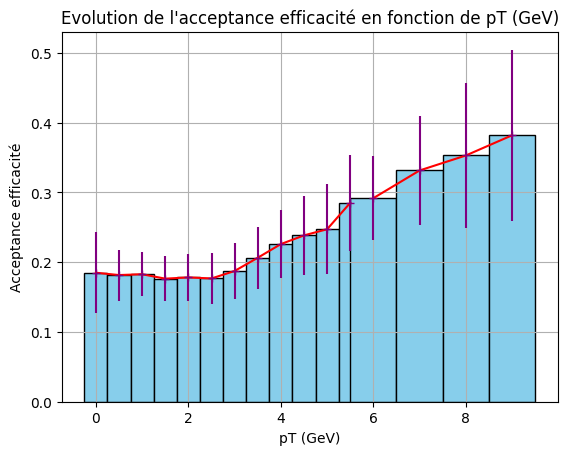

In [13]:
######################################### évolution de l'acceptance efficacité en fonction de pT ##########################################
plt.figure()       
plt.errorbar(Bins_rec_min[:-1],acceptance_eff_min, yerr=err_acceptance_eff_min, fmt='+',color = 'purple', label = 'erreur')
plt.errorbar(Bins_rec_max[:-1],acceptance_eff_max, yerr=err_acceptance_eff_max, fmt='+',color = 'purple', label = 'erreur')

width_min = 6/len(Bins_rec_min[:-1])
width_max = 4/len(Bins_rec_max[:-1])

plt.bar(Bins_rec_min[:-1], acceptance_eff_min,width = width_min, edgecolor='black', color='skyblue')
plt.bar(Bins_rec_max[:-1], acceptance_eff_max,width = width_max, edgecolor='black', color='skyblue')

#plt.hist(Bins_rec[1:])
plt.plot(Bins_rec_min[:-1], acceptance_eff_min,'r')
plt.plot(Bins_rec_max[:-1], acceptance_eff_max,'r')
plt.xlabel('pT (GeV)')
plt.ylabel("Acceptance efficacité")
plt.title("Evolution de l'acceptance efficacité en fonction de pT (GeV)")
plt.grid(True)
plt.show()

In [28]:
#acceptance efficacité en fonction de la rapidité
y_rec = (jpsi_combi.muon1 + jpsi_combi.muon2).rapidity
y_gen = (jpsi_combi_gen.muonA + jpsi_combi_gen.muonB).rapidity

print("rapidité des jpsi reconstruit : ",y_rec)
print("rapidité des jpsi généré : ",y_gen)

# Appliquer le filtre de rapidité
filtered_y_rec = y_rec[(y_rec <= -2.5) & (y_rec >= -4)]
y_rec_f = ak.flatten(filtered_y_rec)

filtered_y_gen = y_gen[(y_gen <= -2.5) & (y_gen >= -4)]
y_gen_f = ak.flatten(filtered_y_gen)

print("rapidité filtré des jpsi reconstruit : ",y_rec_f)
print("rapidité filtré des jpsi généré : ",y_gen_f)


#histo pour la rapidité des jpsi reconstruit
yN_rec, yBins_rec = np.histogram(y_rec_f,bins=50) #yN_rec est le nombre de Jpsi reconstruit dans chaque intervalle en y
print("y_rec = ", yBins_rec)

#histo pour la rapidité des jpsi généré
yN_gen, yBins_gen = np.histogram(y_gen_f,bins=50) #yN_rec est le nombre de Jpsi reconstruit dans chaque intervalle en y
print("y_gen = ", yBins_gen)


rapidité des jpsi reconstruit :  [[-3.04], [-3.08], [-3.89], [-3.73], ..., [-2.94], [-3.83], [-3.46], [-2.57]]
rapidité des jpsi généré :  [[-3.8], [-3.01], [-2.69], [-2.51], ..., [-3.04], [-3.29], [-3.63], [-4.07]]
rapidité filtré des jpsi reconstruit :  [-3.04, -3.08, -3.89, -3.73, -3.23, ..., -3.16, -2.94, -3.83, -3.46, -2.57]
rapidité filtré des jpsi généré :  [-3.8, -3.01, -2.69, -2.51, -3.6, -2.55, ..., -3.93, -2.89, -3.04, -3.29, -3.63]
y_rec =  [-4, -3.97, -3.94, -3.91, -3.88, -3.85, ..., -2.62, -2.59, -2.56, -2.53, -2.5]
y_gen =  [-4, -3.97, -3.94, -3.91, -3.88, -3.85, ..., -2.62, -2.59, -2.56, -2.53, -2.5]


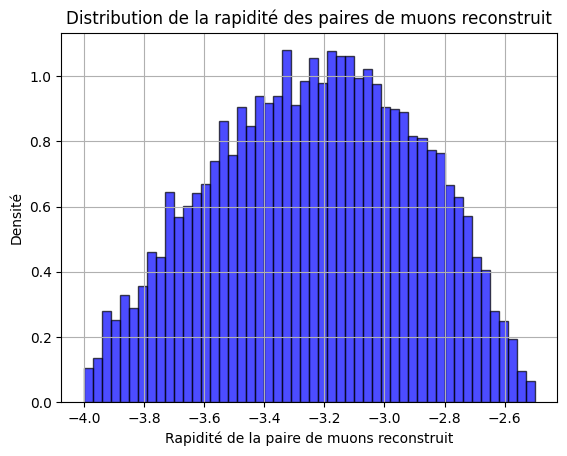

In [25]:
# Affichage de l'histogramme
plt.hist(y_rec_f, bins=50, density=True, alpha=0.7, color='b', edgecolor='black')
# Ajout des labels et du titre
plt.xlabel("Rapidité de la paire de muons reconstruit")
plt.ylabel("Densité")
plt.title("Distribution de la rapidité des paires de muons reconstruit")
plt.grid(True)

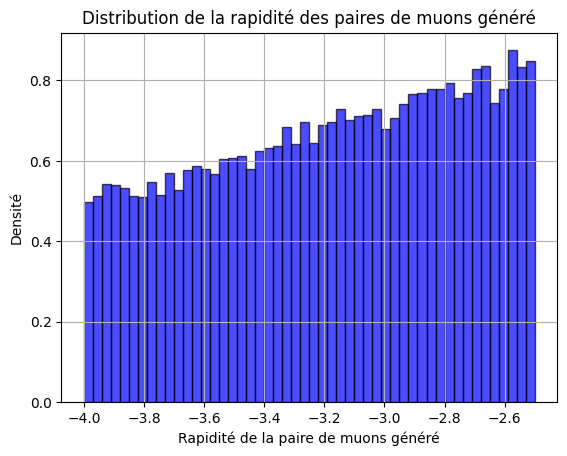

In [26]:
# Affichage de l'histogramme
plt.hist(y_gen_f, bins=50, density=True, alpha=0.7, color='b', edgecolor='black')
# Ajout des labels et du titre
plt.xlabel("Rapidité de la paire de muons généré")
plt.ylabel("Densité")
plt.title("Distribution de la rapidité des paires de muons généré")
plt.grid(True)

In [36]:
######################################### calcul de l'acceptance efficacité en fonction de la rapidité##########################################
#err_N_rec_y = [(yN_rec[i])**(0.5) for i in range(len(yN_rec))]
err_N_rec_y = np.sqrt(yN_rec)
#err_N_gen_y = [(yN_gen[i])**(0.5) for i in range(len(yN_gen))]
err_N_gen_y = np.sqrt(yN_gen)
#acceptance_eff_y = [float(yN_rec[i]/yN_gen[i]) for i in range(len(yN_rec))]
#err_acceptance_eff_y = [float(((err_N_rec_y[i]**2)/(yN_rec[i]**2) + (err_N_gen_y[i]**2)/(yN_gen[i]**2))**(0.5)) for i in range(len(yN_rec))] #delta(AxE)/(AxE)

# Calcul de l'acceptance efficacité et son erreur
acceptance_eff_y = yN_rec / yN_gen  # Converti automatiquement en array NumPy
err_acceptance_eff_y = acceptance_eff_y * np.sqrt((err_N_rec_y / yN_rec) ** 2 + (err_N_gen_y / yN_gen) ** 2)

print("acceptance_eff en fonction de la rapidité = ", acceptance_eff_y)

acceptance_eff en fonction de la rapidité =  [0.0525, 0.0668, 0.13, 0.117, 0.154, ..., 0.0947, 0.08, 0.0557, 0.0292, 0.0192]


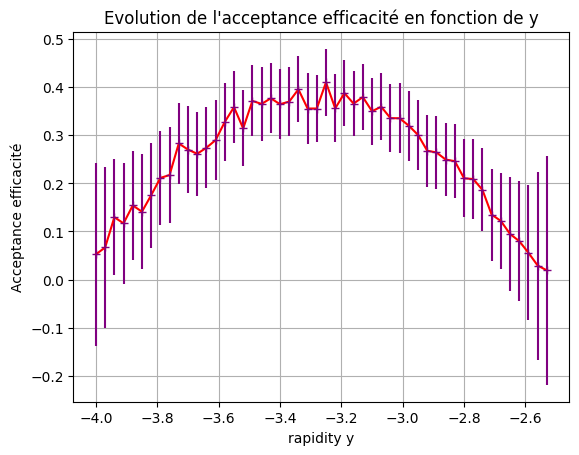

In [32]:
######################################### évolution de l'acceptance efficacité en fonction de y ##########################################
plt.figure()       
plt.errorbar(yBins_rec[:-1],acceptance_eff_y, yerr=err_acceptance_eff_y, fmt='+',color = 'purple', label = 'erreur')
#width = 10/len(Bins_rec[:-1])
#plt.bar(yBins_rec[:-1], acceptance_eff_y, edgecolor='black', color='skyblue')
#plt.hist(Bins_rec[1:])
plt.plot(yBins_rec[:-1], acceptance_eff_y,'r')
plt.xlabel('rapidity y')
plt.ylabel("Acceptance efficacité")
plt.title("Evolution de l'acceptance efficacité en fonction de y")
plt.grid(True)
plt.show()

In [37]:
# Calcul de la moyenne pondérée
weights = 1 / err_acceptance_eff_y**2  # Poids = 1/sigma^2 (array NumPy)
acceptance_eff_mean = np.sum(acceptance_eff_y * weights) / np.sum(weights)
err_acceptance_eff_mean = np.sqrt(1 / np.sum(weights))

# Affichage des résultats
print(f"Acceptance efficacité moyenne : {acceptance_eff_mean:.5f} ± {err_acceptance_eff_mean:.5f}")

Acceptance efficacité moyenne : 0.12912 ± 0.00208


In [48]:
####################################### Calcul de l'acceptance efficacité moyenne avec fit gaussien ##########################
# Fonction gaussienne
def gauss(x, A, mu, sigma):
    return A * np.exp(- (x - mu) ** 2 / (2 * sigma ** 2))

# Calcul de l'acceptance efficacité
acceptance_eff_y = yN_rec / yN_gen

# Vérification : convertir en tableau NumPy
acceptance_eff_y = np.array(acceptance_eff_y, dtype=float)

# Vérifier s'il y a des NaN ou Inf (sinon curve_fit plante)
if np.isnan(acceptance_eff_y).any() or np.isinf(acceptance_eff_y).any():
    raise ValueError("Des valeurs NaN ou infinies sont présentes dans acceptance_eff_y !")
    
# Création d'un histogramme des valeurs
hist_vals, bin_edges = np.histogram(acceptance_eff_y, bins=20, density=True)

# Vérifier si l'histogramme contient des valeurs exploitables
valid = hist_vals > 0  # Filtrer les bins vides
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_centers = bin_centers[valid]
hist_vals = hist_vals[valid]

if len(bin_centers) < 5:  # Moins de 5 points => Fit difficile
    raise ValueError("Pas assez de points pour un ajustement fiable ! Augmente le nombre de données ou de bins.")

# Définition des valeurs initiales améliorées
p0 = [np.max(hist_vals), np.mean(acceptance_eff_y), np.std(acceptance_eff_y)]

# Ajustement du fit gaussien avec plus d'itérations
popt, pcov = curve_fit(gauss, bin_centers, hist_vals, p0=p0, maxfev=5000)
# Affichage des résultats
print(f"Acceptance efficacité moyenne (fit gaussien) : {mu_fit:.5f} ± {sigma_fit:.5f}")

# Tracé des données et du fit
x_fit = np.linspace(min(acceptance_eff_y), max(acceptance_eff_y), 100)
y_fit = gauss(x_fit, *popt)

plt.hist(acceptance_eff_y, bins=10, density=True, alpha=0.6, color='g', label="Données")
plt.plot(x_fit, y_fit, 'r--', label="Fit Gaussien")
plt.xlabel("Acceptance x Efficiency")
plt.ylabel("Densité")
plt.legend()
plt.show()

/tmp/ipykernel_210/2955424215.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  acceptance_eff_y = np.array(acceptance_eff_y, dtype=float)


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.